# z-Transform
The spectrum $X(f)$ of a time-discrete signal $x(n)$ with sampling rate $r$ can be evaluated by the z-transform

$X(z)=\sum_{n=-\infty}^\infty x(n)\cdot z^{-n}$ with

$z=e^{j2\pi fT}$ and $T=\frac{1}{r}$:

$X(f)=\sum_{n=-\infty}^\infty x(n)\cdot e^{-j2\pi f n/r}$

The z-transform can only be evaluated numerically, if the input signal $x(n)$ has finite length.
for the z-transform, the analysis frequencies $f$ must be known.

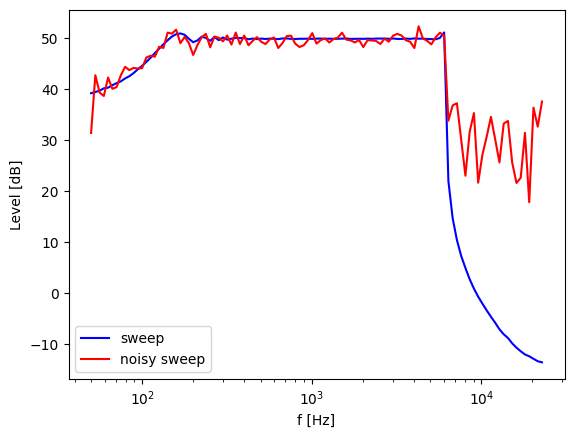

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def EvaluateSpectrum(x, r):
    LowestFrequency = 50
    HighestFrequency = r/2
    NumberOfFrequencyBins = 12*np.log2(HighestFrequency / LowestFrequency)
    f = 50 * (2**(np.arange(NumberOfFrequencyBins) / 12))
    X = np.zeros(f.shape, dtype = complex)
    for n in range(x.shape[0]):
        X += x[n] * np.exp(-1j*2*np.pi*f*n/r)
    X = 20*np.log10(np.abs(X))
    return X, f

r = 48000
f = np.arange(r)/r * 3000 + 100
t = np.arange(r)/r
x = np.sin(2*np.pi*f*t)
y = x + 0.2*np.random.randn(x.shape[0])
X, f = EvaluateSpectrum(x, r)
Y, f = EvaluateSpectrum(y, r)
plt.semilogx(f, X, 'b', label="sweep")
plt.semilogx(f, Y, 'r', label="noisy sweep")
plt.xlabel('f [Hz]')
plt.ylabel('Level [dB]')
plt.legend(loc="lower left")
plt.show()